In [1]:
import torch
import numpy as np
import logging

In [2]:
from libs_to_improve.client import Client, SplitType
from libs_to_improve.model import ContextAwareActor, ContextAwareCritic, Recommender, RecommenderTrainer

In [3]:
import os
from dotenv import load_dotenv

load_dotenv()

# Configuración de logs
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [4]:
USER_ID = "user_55239"
SELECTED_USER_COMPLETE_PATH = f"/mnt/ssd/Carrera/5th_Year/X_SEMESTER/PFC_3/Dataset/processed_users/{USER_ID}_processed.csv"
EMBEDDING_DIM = 64


API_URL = os.getenv("API_URL")
EMBEDDING_URL= f"{API_URL}/info"

In [5]:
def calcular_recompensa_normalizada(interaction_count: int, interaction_ratio: float) -> float:
    """Recompensa acotada entre 0 y 1 para estabilidad."""
    count_factor = np.log1p(interaction_count) / np.log1p(10)
    alpha = 0.6
    beta = 0.4
    recompensa = alpha * count_factor + beta * interaction_ratio
    return float(np.clip(recompensa, 0.0, 1.0))

def ejemplo_get_embedding(track_id: str) -> torch.Tensor:
    import requests
    response = requests.get(f"{EMBEDDING_URL}/{track_id}?info_type=embedding")
    if response.status_code == 200:
        embedding = response.json().get("data", {}).get("embedding", [])
        return torch.tensor(embedding, dtype=torch.float32)
    else:
        logging.error(f"Error al obtener embedding para track_id {track_id}: {response.status_code}")
        return torch.zeros(EMBEDDING_DIM, dtype=torch.float32)
    

In [6]:
logging.info(f"Iniciando configuración para el usuario: {USER_ID}")

logging.info(f"Cargando datos del cliente desde: {SELECTED_USER_COMPLETE_PATH}")
client = Client(
    path=SELECTED_USER_COMPLETE_PATH,
    recompensa_func=calcular_recompensa_normalizada,
    get_embedding_func=ejemplo_get_embedding,
    batch_size=32,
    split_ratios=(0.7, 0.15, 0.15),
    cache_path="cache_client.json",
    embeddings_path="/mnt/ssd/Carrera/Datasets/Music4all-Onion/music_4_all_compress_64.csv"
)

2026-03-22 22:11:31,835 - INFO - Iniciando configuración para el usuario: user_55239
2026-03-22 22:11:31,836 - INFO - Cargando datos del cliente desde: /mnt/ssd/Carrera/5th_Year/X_SEMESTER/PFC_3/Dataset/processed_users/user_55239_processed.csv


⏳ Cargando embeddings desde CSV: /mnt/ssd/Carrera/Datasets/Music4all-Onion/music_4_all_compress_64.csv...
✅ 109,262 embeddings cargados exitosamente.

📊 Iniciando procesamiento de 226,609 filas...
💾 Cache inicial: 109,262 embeddings


Procesando datos:   2%|▏         | 5597/226609 [00:00<00:23]

⚠️  Error fila 3301: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...
⚠️  Error fila 5190: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...


Procesando datos:   5%|▍         | 10896/226609 [00:01<00:26]

...

⚠️  Error fila 46285: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...


Procesando datos:  23%|██▎       | 50993/226609 [00:06<00:20]

⚠️  Error fila 49219: Invalid URL 'None/info/mrKUj710cpf4eMQZ?info_type=embedding': No scheme supplied. Perhaps you meant ...


Procesando datos: 100%|█████████▉| 226594/226609 [00:25<00:00]


✅ PROCESAMIENTO COMPLETADO - RESUMEN
📈 Estadísticas:
   • Total filas: 226,609
   • Procesadas exitosamente: 226,594 (99.99%)
   • Errores: 15 (0.01%)
   • Cache hits: 226,594 (100.00%)
   • Cache misses: 0 (0.00%)
   • Nuevos embeddings: 0

⏱️  Tiempos:
   • Total: 25.88s (0.43min)
   • Por fila: 0.11ms
   • Velocidad: 8757.1 filas/segundo

💾 Cache final: 109,262 embeddings

⚠️  Se encontraron 15 errores durante el procesamiento
División creada: Train=158615, Test=33989, Validation=33990


In [7]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
logging.info(f"Dispositivo detectado: {DEVICE}")

logging.info("Inicializando modelos ContextAwareActor y ContextAwareCritic...")
actor = ContextAwareActor(embedding_dim=EMBEDDING_DIM).to(DEVICE)
critic = ContextAwareCritic(action_dim=EMBEDDING_DIM).to(DEVICE)

logging.info("Configurando Recommender y RecommenderTrainer...")
recommender = Recommender(client=client)
recommender_trainer = RecommenderTrainer(
    actor=actor,
    critic=critic,
    client=client,
    recommender=recommender,
)

2026-03-22 22:20:12,843 - INFO - Dispositivo detectado: cuda
2026-03-22 22:20:12,846 - INFO - Inicializando modelos ContextAwareActor y ContextAwareCritic...
2026-03-22 22:20:13,131 - INFO - Configurando Recommender y RecommenderTrainer...


In [8]:
logging.info("Iniciando entrenamiento...")
try:
    history = recommender_trainer.train(
        num_epochs=50,
        epsilon_start=0.9,
        epsilon_end=0.1,
        epsilon_decay=0.995,
        eval_freq=1,
        save_path="modelo_recomendacion"
    )
    logging.info("Entrenamiento completado satisfactoriamente.")
except Exception as e:
    logging.error(f"Error durante el entrenamiento: {e}")

2026-03-22 22:20:28,040 - INFO - Iniciando entrenamiento...


Starting training for 50 epochs in cuda...

Epoch 1/50


Training: 100%|██████████| 1000/1000 [00:15<00:00, 66.08it/s]


Train Metrics:
  actor_loss: -1.0334
  critic_loss: 0.0129
  avg_reward: 0.8563
  gt_avg_reward: 0.7778
  reward_ratio: 1.1008
  precision@1: 1.0000
  recall@1: 1.0000
  precision@5: 0.6000
  recall@5: 0.6000
  map@5: 0.6000
  precision@10: 0.5000
  recall@10: 0.5000
  map@10: 0.4222
  ndcg@1: 0.9203
  ndcg@5: 0.8874
  ndcg@10: 0.8922
  sim_precision@1: 1.0000
  sim_ndcg@1: 1.0000
  sim_precision@5: 0.8000
  sim_ndcg@5: 1.0000
  sim_precision@10: 0.8000
  sim_ndcg@10: 0.9812
  context_coverage_days: 1.0000
  context_coverage_hours: 0.1250
  context_coverage_months: 0.0833
  workday_coverage: 1.0000
  temporal_entropy: -0.0000
  context_variety: 0.3333
  embedding_diversity: 31.7907
  cosine_diversity: 0.6615
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 0.1250
  div_context_coverage_months: 0.0833
  div_workday_coverage: 1.0000
  div_temporal_entropy: -0.0000
  div_context_variety: 0.3333
  novelty_ratio: 0.5800
  rec_length: 100.0000
  gt_length: 100.0000
  rec_rew

Training: 100%|██████████| 1000/1000 [00:15<00:00, 64.64it/s]


...

Train Metrics:
  actor_loss: -3.0050
  critic_loss: 0.0000
  avg_reward: 0.9992
  gt_avg_reward: 0.7778
  reward_ratio: 1.2846
  precision@1: 1.0000
  recall@1: 1.0000
  precision@5: 1.0000
  recall@5: 1.0000
  map@5: 1.0000
  precision@10: 1.0000
  recall@10: 1.0000
  map@10: 1.0000
  ndcg@1: 0.9203
  ndcg@5: 0.9730
  ndcg@10: 0.9825
  sim_precision@1: 1.0000
  sim_ndcg@1: 1.0000
  sim_precision@5: 1.0000
  sim_ndcg@5: 1.0000
  sim_precision@10: 1.0000
  sim_ndcg@10: 1.0000
  context_coverage_days: 1.0000
  context_coverage_hours: 0.1250
  context_coverage_months: 0.0833
  workday_coverage: 1.0000
  temporal_entropy: -0.0000
  context_variety: 0.3333
  embedding_diversity: 20.6375
  cosine_diversity: 0.4461
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 0.1250
  div_context_coverage_months: 0.0833
  div_workday_coverage: 1.0000
  div_temporal_entropy: -0.0000
  div_context_variety: 0.3333
  novelty_ratio: 0.0800
  rec_length: 100.0000
  gt_length: 100.0000
  rec_rew

Training: 100%|██████████| 1000/1000 [00:21<00:00, 45.51it/s]


Train Metrics:
  actor_loss: -3.0365
  critic_loss: 0.0000
  avg_reward: 0.9992
  gt_avg_reward: 0.7778
  reward_ratio: 1.2846
  precision@1: 1.0000
  recall@1: 1.0000
  precision@5: 1.0000
  recall@5: 1.0000
  map@5: 1.0000
  precision@10: 1.0000
  recall@10: 1.0000
  map@10: 1.0000
  ndcg@1: 0.9203
  ndcg@5: 0.9730
  ndcg@10: 0.9825
  sim_precision@1: 1.0000
  sim_ndcg@1: 1.0000
  sim_precision@5: 1.0000
  sim_ndcg@5: 1.0000
  sim_precision@10: 1.0000
  sim_ndcg@10: 1.0000
  context_coverage_days: 1.0000
  context_coverage_hours: 0.1250
  context_coverage_months: 0.0833
  workday_coverage: 1.0000
  temporal_entropy: -0.0000
  context_variety: 0.3333
  embedding_diversity: 20.5036
  cosine_diversity: 0.4434
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 0.1250
  div_context_coverage_months: 0.0833
  div_workday_coverage: 1.0000
  div_temporal_entropy: -0.0000
  div_context_variety: 0.3333
  novelty_ratio: 0.0900
  rec_length: 100.0000
  gt_length: 100.0000
  rec_rew

2026-03-22 22:38:36,648 - INFO - Entrenamiento completado satisfactoriamente.



Test Metrics:
  avg_reward: 0.7588
  gt_avg_reward: 0.9819
  reward_ratio: 0.7728
  precision@1: 1.0000
  recall@1: 1.0000
  precision@5: 0.4000
  recall@5: 0.4000
  map@5: 0.2800
  precision@10: 0.7000
  recall@10: 0.7000
  map@10: 0.4463
  ndcg@1: 1.0000
  ndcg@5: 0.8793
  ndcg@10: 0.9217
  sim_precision@1: 1.0000
  sim_ndcg@1: 1.0000
  sim_precision@5: 0.8000
  sim_ndcg@5: 0.9575
  sim_precision@10: 0.9000
  sim_ndcg@10: 0.9336
  context_coverage_days: 1.0000
  context_coverage_hours: 0.1250
  context_coverage_months: 0.0833
  workday_coverage: 1.0000
  temporal_entropy: -0.0000
  context_variety: 0.3333
  embedding_diversity: 21.7921
  cosine_diversity: 0.5280
  div_context_coverage_days: 1.0000
  div_context_coverage_hours: 0.1250
  div_context_coverage_months: 0.0833
  div_workday_coverage: 1.0000
  div_temporal_entropy: -0.0000
  div_context_variety: 0.3333
  novelty_ratio: 0.0800
  rec_length: 100.0000
  gt_length: 100.0000
  rec_reward_mean: 0.7588
  rec_reward_std: 0.2888
  


Visualizando historial de entrenamiento...


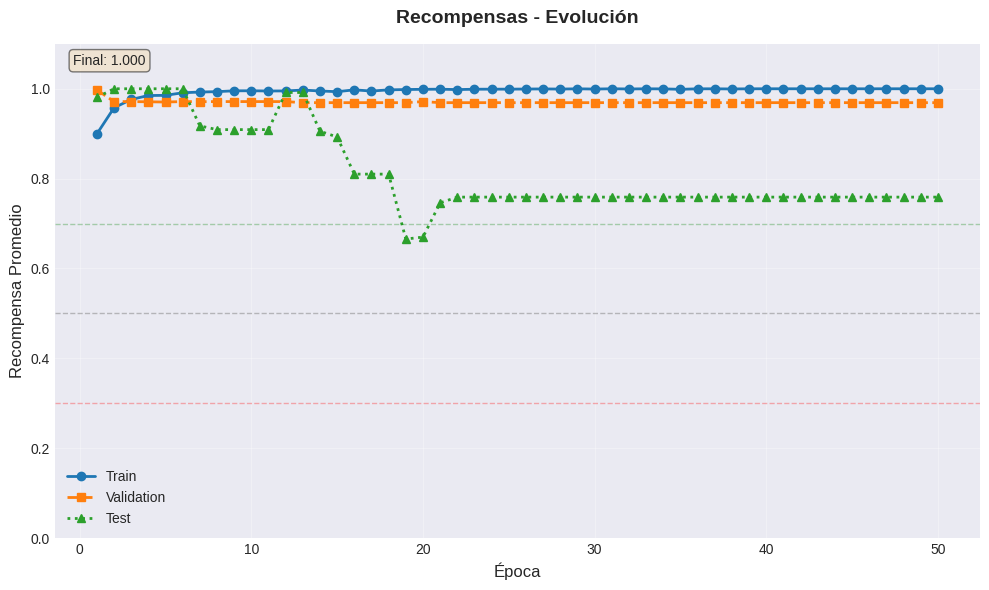

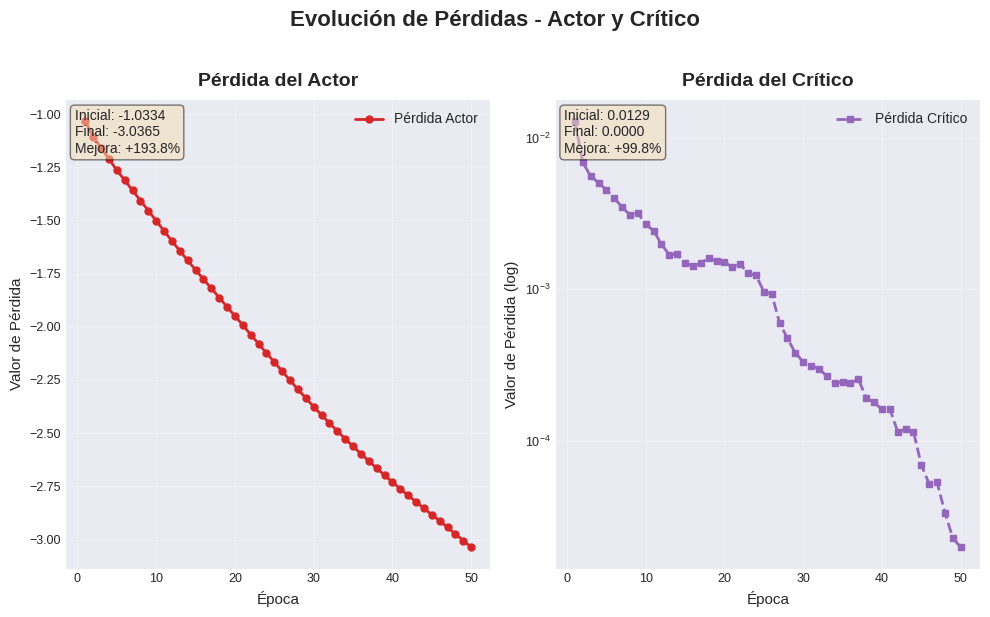

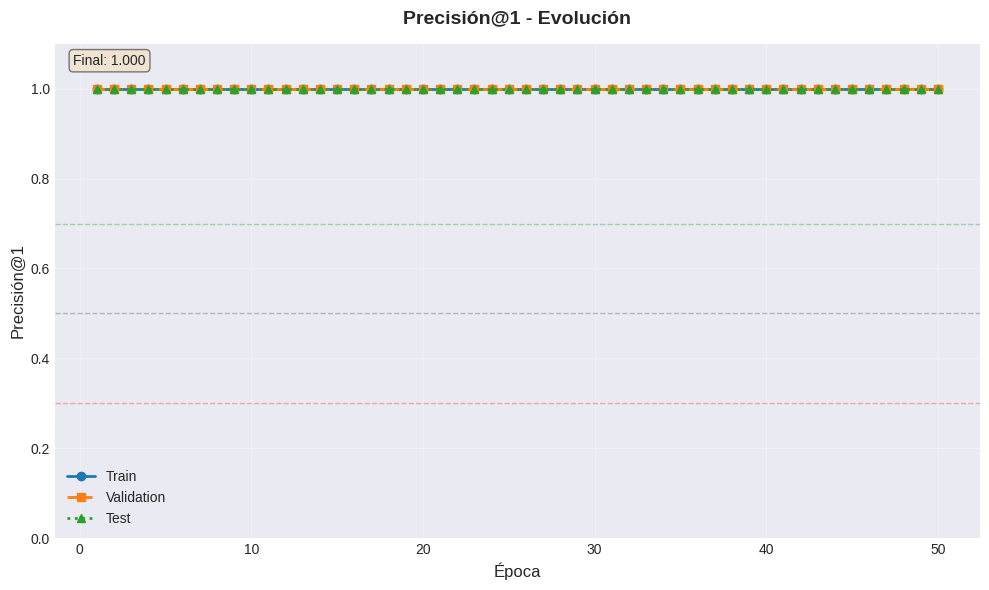

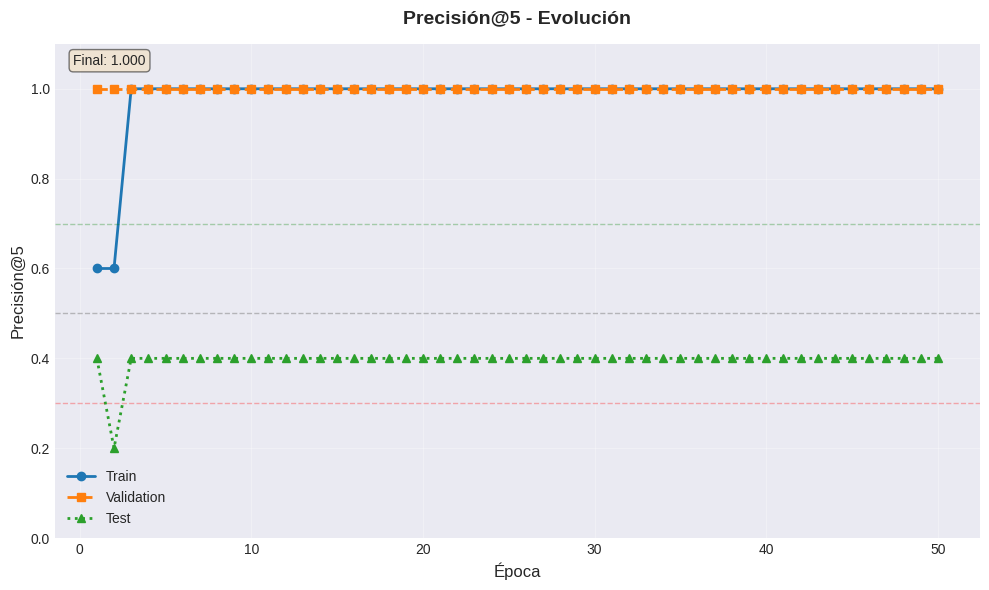

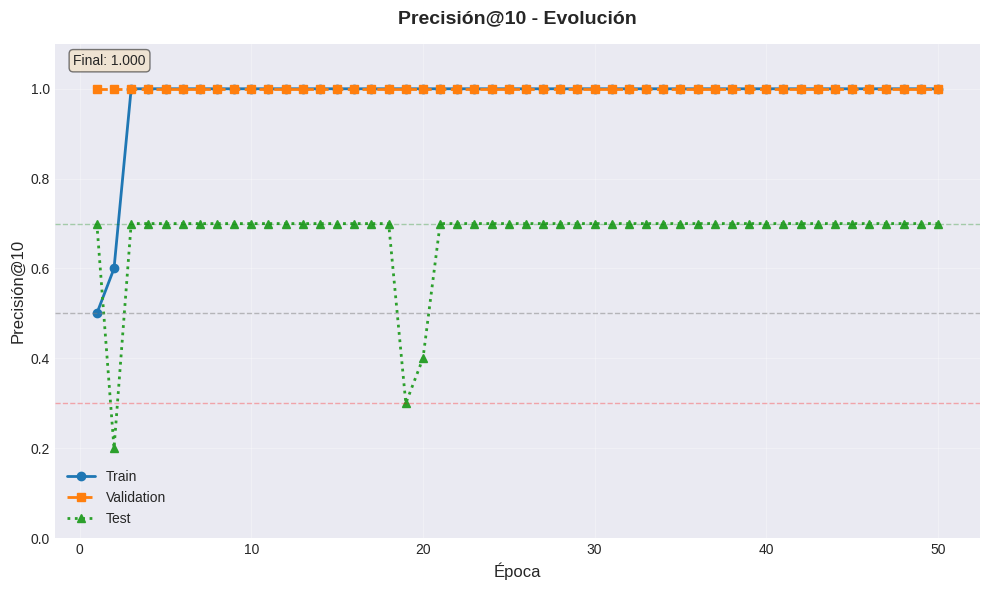

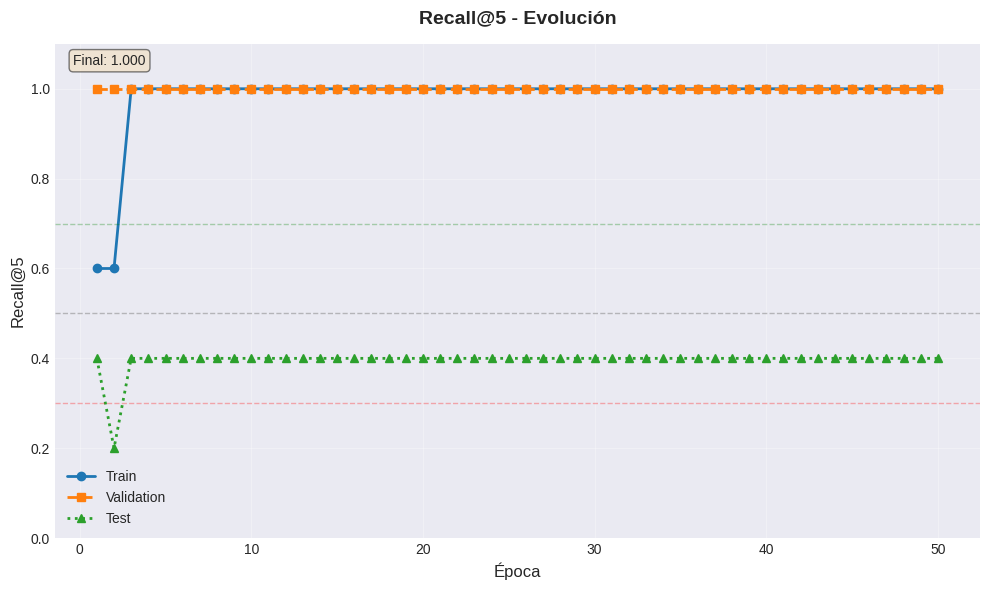

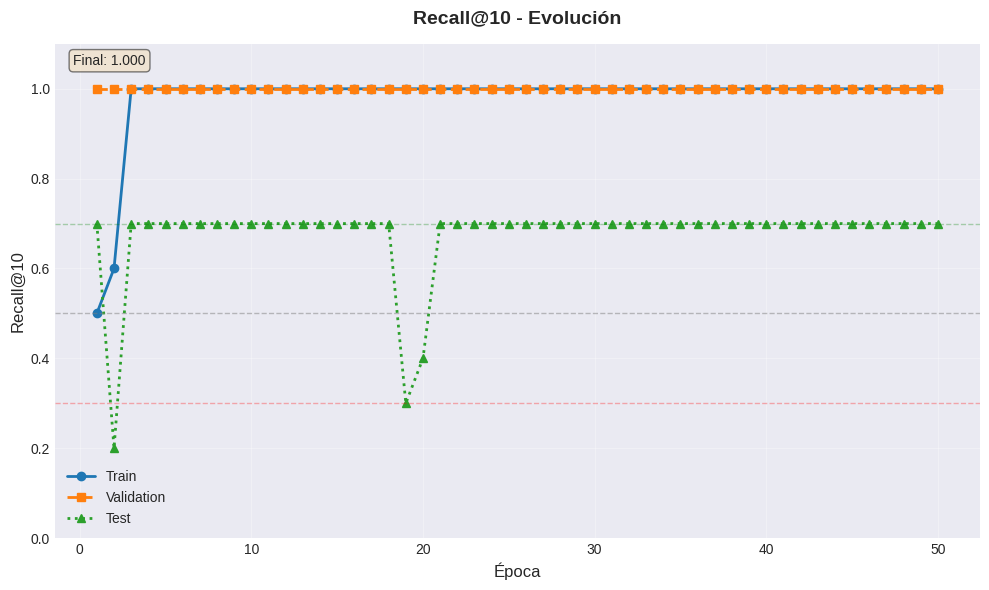

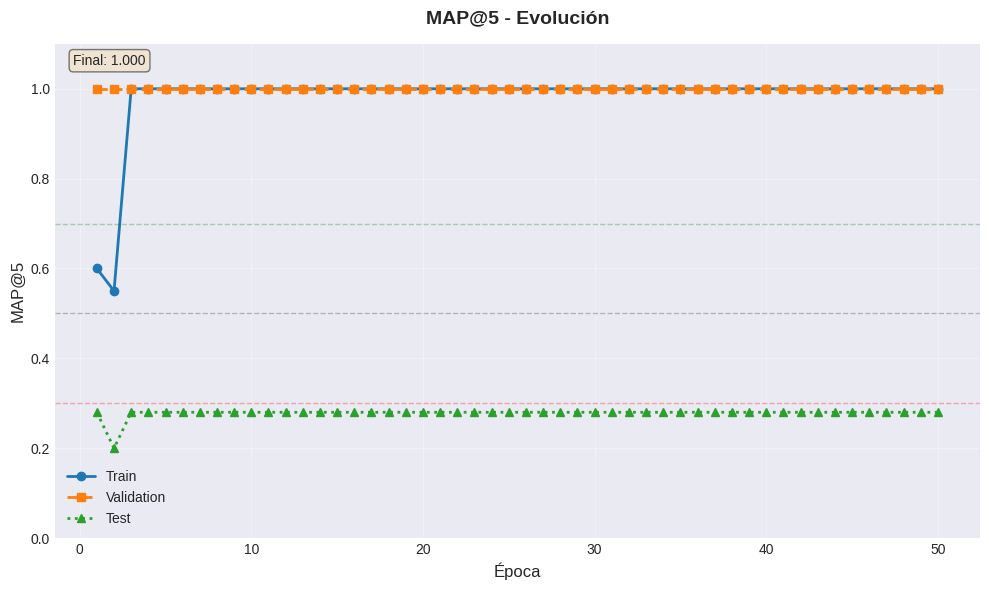

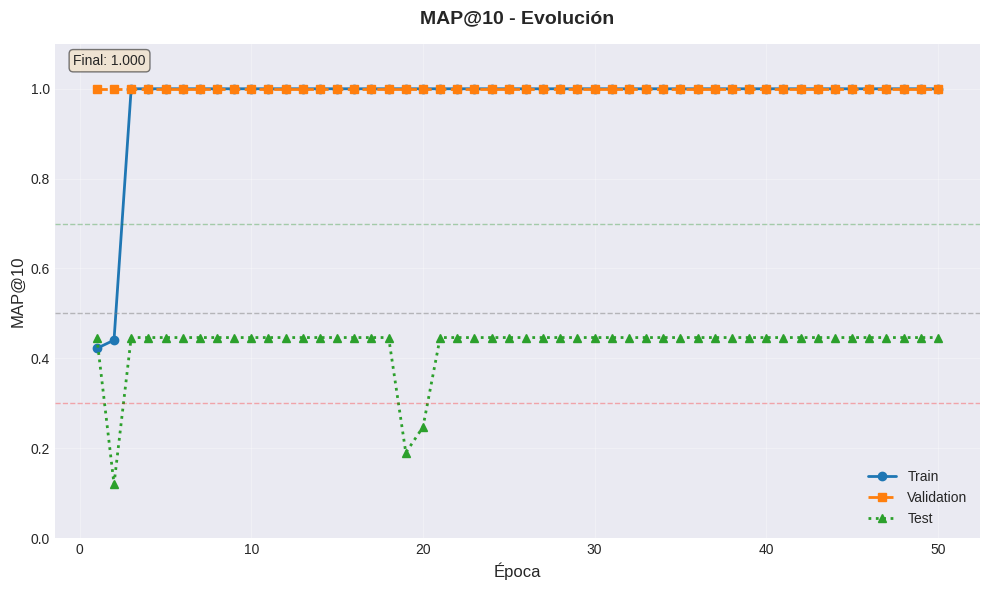

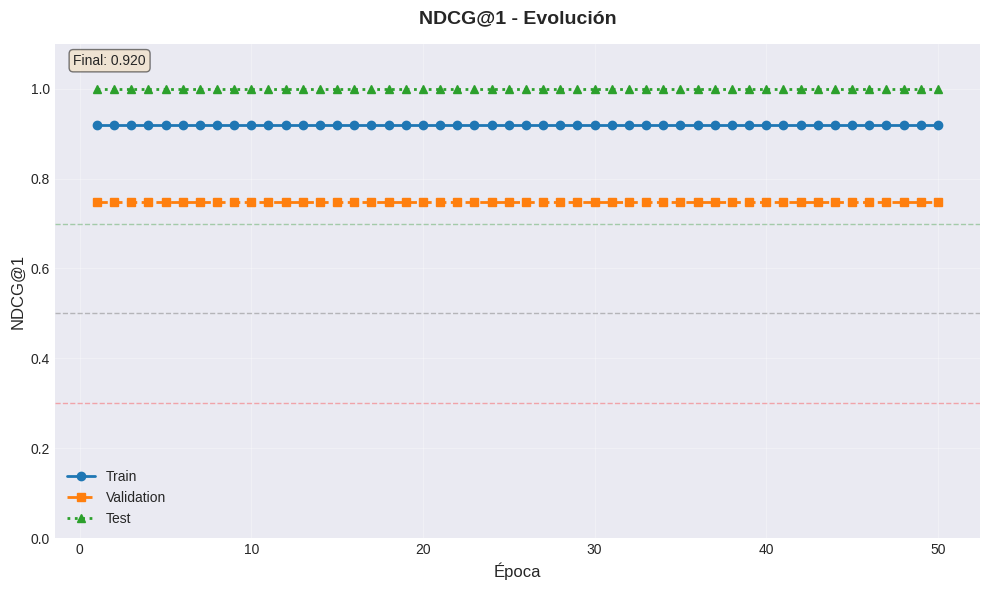

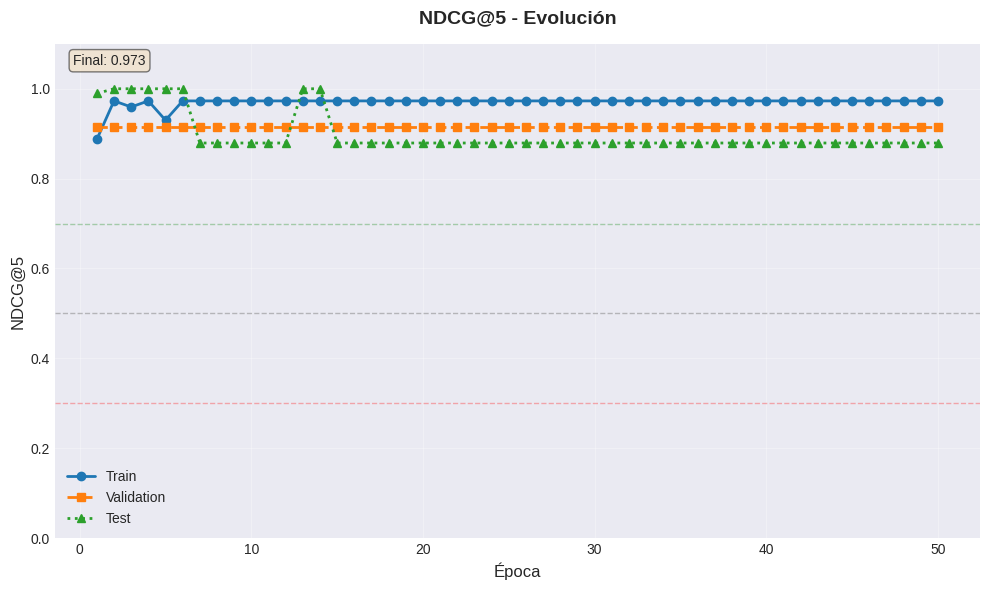

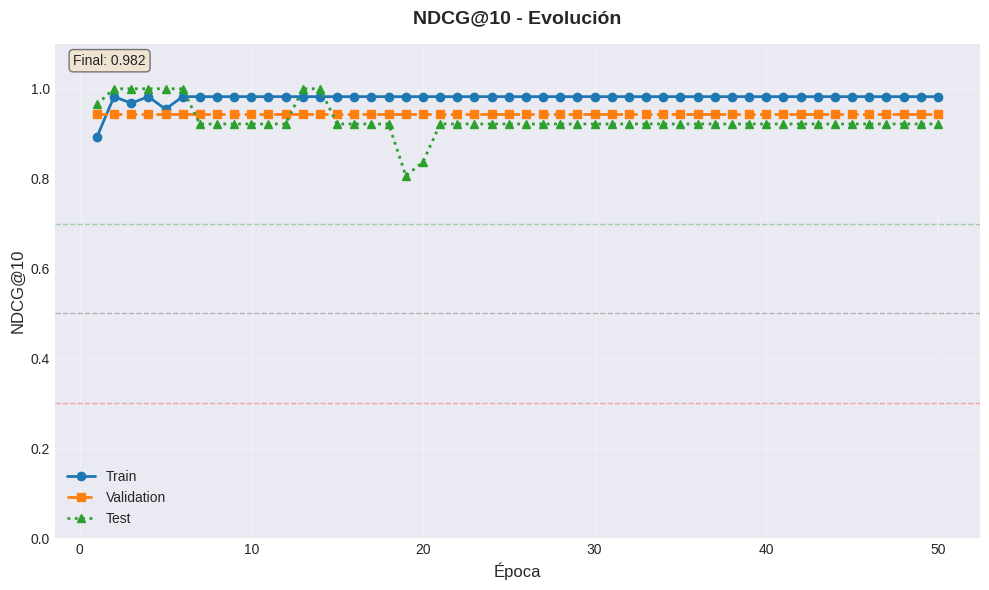

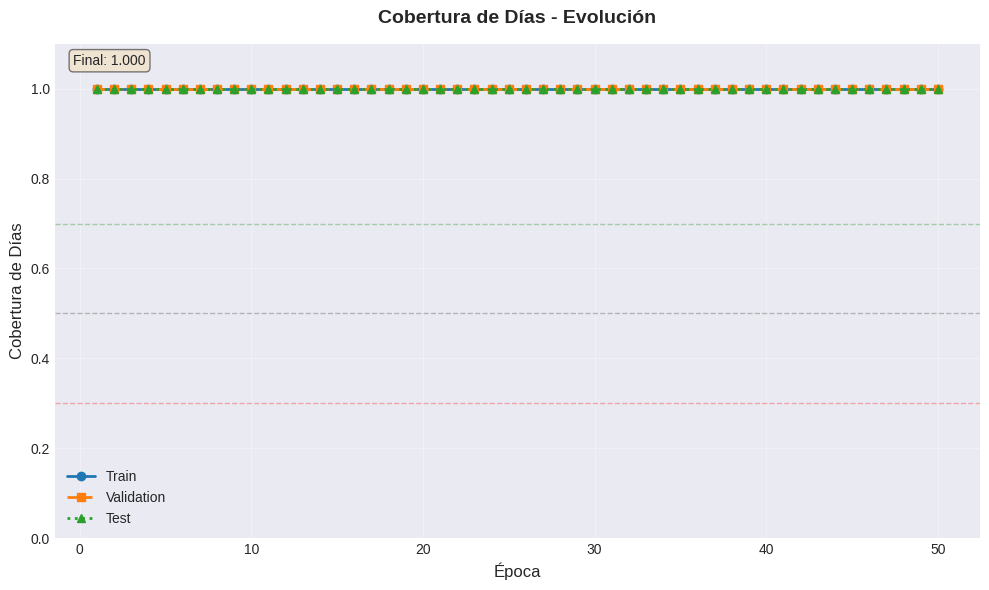

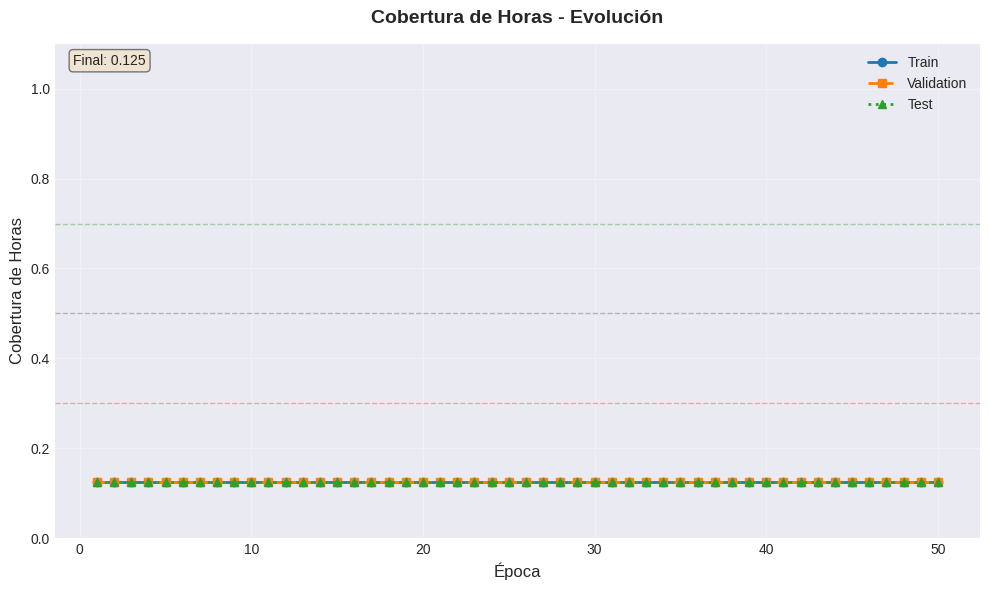

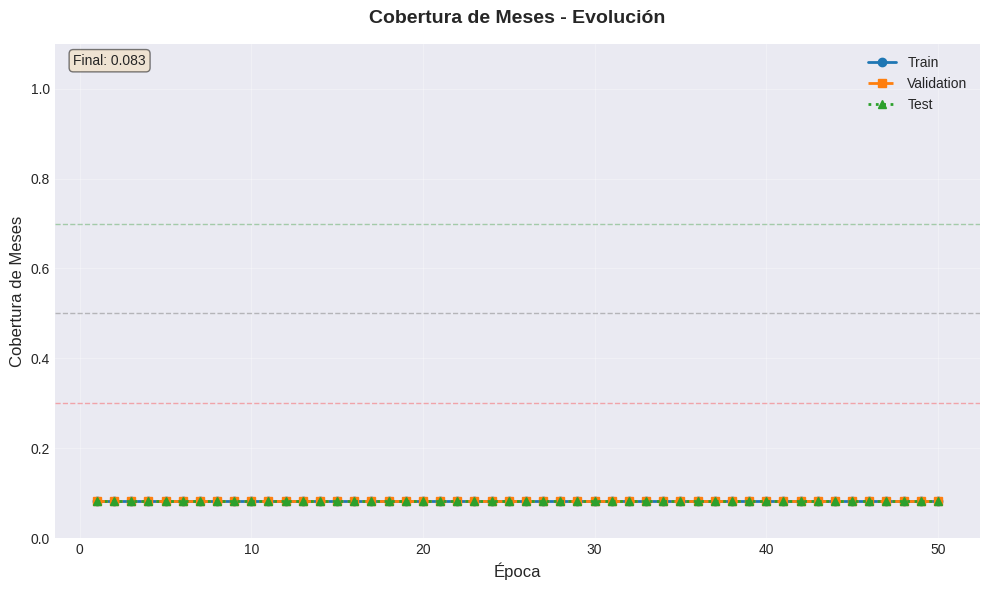

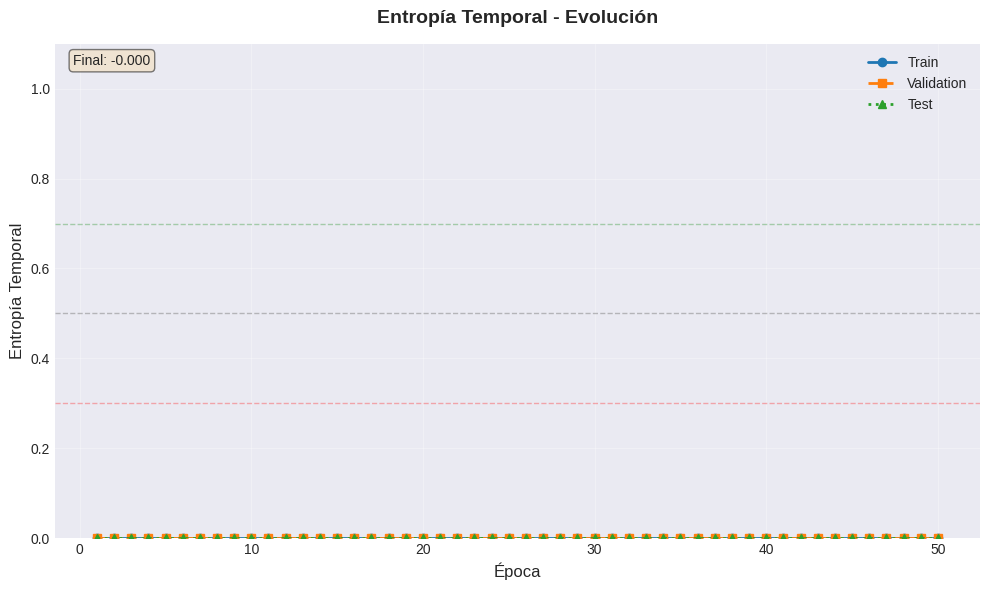

✅ Gráficas individuales creadas


In [9]:
print("\nVisualizando historial de entrenamiento...")
recommender_trainer.plot_individual_metrics()